# Einfluss hoher Temperaturen auf die städtische Luftqualität

## Fallstudie Frankfurt am Main 2016–2025 und Prognose des dominierenden Schadstoffs

**Forschungsfrage:** Verschlechtert Hitze die Luftqualität insgesamt, oder
verändert sie vor allem die Zusammensetzung der Luftschadstoffe?

**These:** Hohe Temperaturen erhöhen insbesondere die Ozonbelastung, während
die Stickstoffdioxidbelastung gleichzeitig sinken kann. Dadurch verändert sich
an heißen Tagen der dominierende Luftschadstoff.

**Prognoseziel:** Vorhersage, welcher Luftschadstoff die Luftqualität am
Folgetag am stärksten beeinträchtigt.

Als „dominierend“ gilt der Schadstoff mit dem höchsten stündlichen Einzelindex
des aktuellen UBA-Luftqualitätsindex (LQI). So werden Ozon, NO₂, PM₁₀, PM₂,₅
und SO₂ trotz unterschiedlicher Konzentrationsskalen vergleichbar.

## 1. Setup und Datenstand

Die Rohdaten sind lokal eingefroren. `scripts/download_data.py` lädt zehn
Jahresdateien des HLNUG sowie fünf stündliche DWD-Reihen. Zufällige
Verfahren verwenden einen festen Startwert; Rohdaten werden nie überschrieben.

In [1]:
from __future__ import annotations

import json
import math
import re
import zipfile
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import mannwhitneyu
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "figures"
MODELS_DIR = ROOT / "models"
for directory in (PROCESSED_DIR, FIGURES_DIR, MODELS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

START_YEAR, END_YEAR = 2016, 2025
AIR_STATION, DWD_STATION = "DEHE005", "01420"
POLLUTANTS = ["O3", "NO2", "PM10", "PM2.5", "SO2"]
LABELS = {
    "O3": "Ozon (O$_3$)", "NO2": "Stickstoffdioxid (NO$_2$)",
    "PM10": "Feinstaub (PM$_{10}$)", "PM2.5": "Feinstaub (PM$_{2,5}$)",
    "SO2": "Schwefeldioxid (SO$_2$)",
}
COLORS = {"O3": "#d95f02", "NO2": "#1f78b4", "PM10": "#7570b3", "PM2.5": "#66a61e", "SO2": "#666666"}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.titlesize": 14,
})

manifest = json.loads((RAW_DIR / "download_manifest.json").read_text(encoding="utf-8"))
display(pd.DataFrame(manifest["stations"]).T)
print(f"Eingefrorene Rohdaten: {sum(item['bytes'] for item in manifest['files']) / 1e6:.1f} MB")

,id,portal_id,name,type,provider,latitude,longitude
air_quality,DEHE005,0617,Frankfurt-Höchst,urban background,HLNUG,50.10175,8.542517
weather,01420,NaN,Frankfurt/Main,NaN,NaN,50.0259,8.5213


Eingefrorene Rohdaten: 13.6 MB


## 2. Daten laden, Zeitstempel vereinheitlichen und räumlich zuordnen

- **Luftqualität:** HLNUG-Station Frankfurt-Höchst (DEHE005), städtischer Hintergrund.
- **Wetter:** DWD-Station Frankfurt/Main (01420), rund 8,6 km entfernt.
- **Zeit:** Die HLNUG-Schnittstelle wird mit UTC-Ausgabe abgefragt; auch die
  DWD-Reihen liegen in UTC vor. Anschließend werden beide Quellen stündlich verbunden.
- **Ort:** Die räumlich nahe DWD-Station wird einmalig über Koordinaten
  zugeordnet; anschließend erfolgt der Join über den Stundenzeitstempel.

Der hier verwendete Zeitraum endet 2025; der genaue Abruf und jede Prüfsumme
stehen im Manifest.

In [2]:
def load_hlnug() -> pd.DataFrame:
    parameter_map = {"15": "O3", "14": "NO2", "44": "PM10", "83": "PM2.5", "18": "SO2"}
    frames = []
    for path in sorted(RAW_DIR.glob(f"hlnug_airquality_{AIR_STATION}_*.json")):
        payload = json.loads(path.read_text(encoding="utf-8"))
        frame = pd.DataFrame.from_dict(payload.get("data", {}), orient="index")
        frame = frame.rename(columns=parameter_map)
        frame["timestamp_utc"] = pd.to_datetime(
            pd.to_numeric(frame.index, errors="coerce"), unit="s", utc=True
        ).tz_localize(None)
        for pollutant in POLLUTANTS:
            frame[pollutant] = pd.to_numeric(frame.get(pollutant), errors="coerce")
        frames.append(frame[["timestamp_utc", *POLLUTANTS]])
    if not frames:
        raise FileNotFoundError("Keine HLNUG-Jahresdateien gefunden. Zuerst scripts/download_data.py ausführen.")
    result = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp_utc"])
    return result.groupby("timestamp_utc", as_index=False)[POLLUTANTS].mean()


def read_dwd_zip(path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(path) as archive:
        product = next(name for name in archive.namelist() if "produkt_" in name.lower() and name.endswith(".txt"))
        frame = pd.read_csv(archive.open(product), sep=";")
    frame.columns = [column.strip() for column in frame.columns]
    return frame


def dwd_timestamp(values: pd.Series, solar: bool = False) -> pd.Series:
    fmt = "%Y%m%d%H:%M" if solar else "%Y%m%d%H"
    parsed = pd.to_datetime(values.astype(str).str.strip(), format=fmt, errors="coerce", utc=True)
    if solar:
        parsed = parsed.dt.round("h")
    return parsed.dt.tz_localize(None)


weather_specs = {
    "air_temperature": {"TT_TU": "temp_c", "RF_TU": "humidity_pct"},
    "wind": {"F": "wind_speed_ms", "D": "wind_direction_deg"},
    "sun": {"SD_SO": "sunshine_h"},
    "precipitation": {"R1": "precip_mm"},
    "solar": {"FG_LBERG": "global_radiation_j_cm2", "FD_LBERG": "diffuse_radiation_j_cm2"},
}

weather_frames = []
for variable, mapping in weather_specs.items():
    frame = read_dwd_zip(RAW_DIR / f"dwd_{variable}_{DWD_STATION}.zip")
    frame.columns = [column.strip() for column in frame.columns]
    frame["timestamp_utc"] = dwd_timestamp(frame["MESS_DATUM"], solar=variable == "solar")
    keep = [column for column in mapping if column in frame]
    frame = frame[["timestamp_utc", *keep]].rename(columns=mapping)
    value_columns = [column for column in frame if column != "timestamp_utc"]
    for column in value_columns:
        frame[column] = pd.to_numeric(frame[column], errors="coerce").replace(-999, np.nan)
    frame = frame.loc[frame["timestamp_utc"].dt.year.between(START_YEAR, END_YEAR)]
    weather_frames.append(frame.groupby("timestamp_utc", as_index=False)[value_columns].mean())

weather = weather_frames[0]
for frame in weather_frames[1:]:
    weather = weather.merge(frame, on="timestamp_utc", how="outer", validate="one_to_one")

air = load_hlnug()
hourly = air.merge(weather, on="timestamp_utc", how="left", validate="one_to_one")
hourly = hourly.loc[hourly["timestamp_utc"].dt.year.between(START_YEAR, END_YEAR)].sort_values("timestamp_utc")

distance_km = 2 * 6371 * math.asin(math.sqrt(
    math.sin(math.radians(50.10175 - 50.0259) / 2) ** 2
    + math.cos(math.radians(50.10175)) * math.cos(math.radians(50.0259))
    * math.sin(math.radians(8.542517 - 8.5213) / 2) ** 2
))
print(f"Räumliche Distanz der Stationen: {distance_km:.2f} km")
print(f"Stündliche Luftqualitätszeilen: {len(air):,}; verbundene Zeilen: {len(hourly):,}")
display(hourly.head())

Räumliche Distanz der Stationen: 8.57 km
Stündliche Luftqualitätszeilen: 87,552; verbundene Zeilen: 87,552


,timestamp_utc,O3,NO2,PM10,PM2.5,SO2,temp_c,humidity_pct,wind_speed_ms,wind_direction_deg,sunshine_h,precip_mm,global_radiation_j_cm2,diffuse_radiation_j_cm2
0,2016-01-01 01:00:00,3.6,42.4,214.7,0.0,4.9,5.2,98.0,1.7,210.0,NaN,0.0,NaN,NaN
1,2016-01-01 02:00:00,5.5,42.0,96.7,NaN,4.9,5.0,97.0,1.2,210.0,NaN,0.0,NaN,NaN
2,2016-01-01 03:00:00,8.4,39.6,68.6,NaN,2.6,5.2,98.0,1.3,190.0,0.0,0.0,NaN,NaN
3,2016-01-01 04:00:00,7.6,39.0,68.2,NaN,1.3,5.0,96.0,1.9,190.0,0.0,0.0,NaN,NaN
4,2016-01-01 05:00:00,9.3,38.8,80.9,NaN,0.8,4.8,96.0,2.8,210.0,0.0,0.0,NaN,NaN


## 3. Datenqualität und Tagesaggregation

Die Analyse nutzt Tageswerte, weil „heißer Tag“ und „dominierender Schadstoff
am Folgetag“ Tageskonzepte sind. Schadstoffe werden als tägliches Maximum der
Stundenwerte bewertet. Meteorologische Größen werden je nach Bedeutung als
Maximum, Mittel oder Summe aggregiert.

Die aktuellen UBA-LQI-Klassengrenzen werden auf die HLNUG-Messwerte aller Jahre
angewandt. Das ist eine bewusste Re-Klassifikation für eine einheitliche
gesundheitliche Skala und keine Behauptung über damals veröffentlichte Indexwerte.

,Variable,Stündliche Vollständigkeit
0,O3,90.1%
1,NO2,90.7%
2,PM10,90.6%
3,PM2.5,60.4%
4,SO2,90.2%
5,Temperatur,99.9%
6,Wind,99.0%
7,Niederschlag,99.6%
8,Sonne,74.5%
9,Globalstrahlung,31.7%


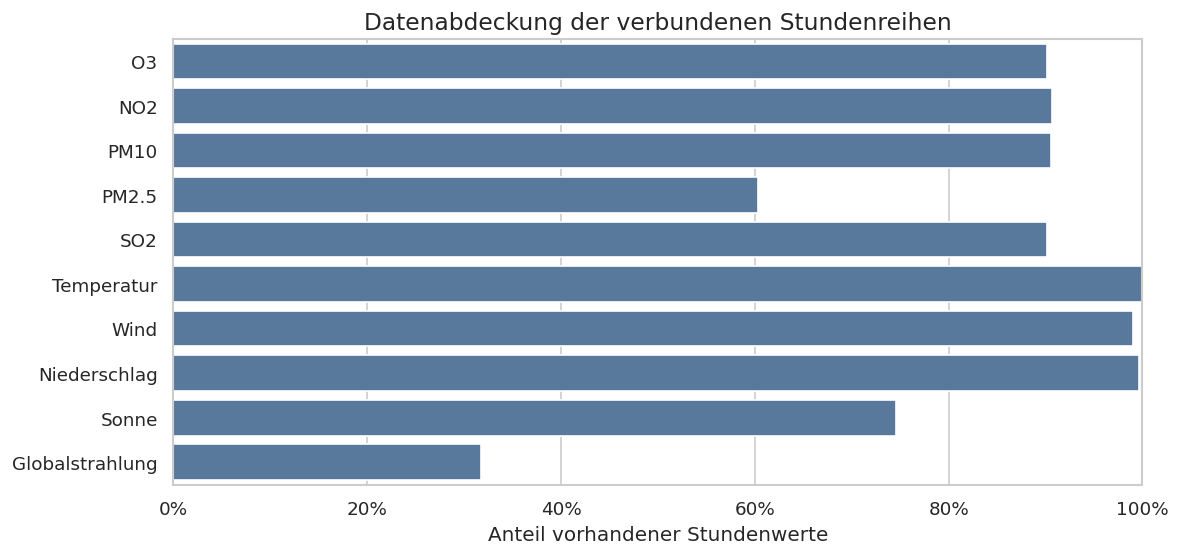

In [3]:
LQI_UPPER = {
    "NO2": [10, 30, 60, 100],
    "PM10": [9, 27, 54, 90],
    "PM2.5": [5, 15, 30, 50],
    "O3": [24, 72, 144, 240],
    "SO2": [10, 30, 60, 100],
}


def continuous_lqi(values: pd.Series, pollutant: str) -> pd.Series:
    bounds = LQI_UPPER[pollutant]
    x = np.asarray(values, dtype=float)
    xp = np.array([0, *bounds, bounds[-1] * 1.5], dtype=float)
    fp = np.arange(0, 6, dtype=float)
    return pd.Series(np.interp(x, xp, fp, left=0, right=5), index=values.index)


local_time = hourly["timestamp_utc"].dt.tz_localize("UTC").dt.tz_convert("Europe/Berlin")
hourly["date"] = local_time.dt.tz_localize(None).dt.normalize()
for pollutant in POLLUTANTS:
    hourly[f"{pollutant}_lqi_score"] = continuous_lqi(hourly[pollutant], pollutant)

aggregations = {
    "temp_max_c": ("temp_c", "max"),
    "temp_mean_c": ("temp_c", "mean"),
    "humidity_mean_pct": ("humidity_pct", "mean"),
    "wind_mean_ms": ("wind_speed_ms", "mean"),
    "wind_max_ms": ("wind_speed_ms", "max"),
    "precip_sum_mm": ("precip_mm", "sum"),
    "sunshine_sum_h": ("sunshine_h", "sum"),
    "global_radiation_sum_j_cm2": ("global_radiation_j_cm2", "sum"),
}
for pollutant in POLLUTANTS:
    aggregations[f"{pollutant}_max"] = (pollutant, "max")
    aggregations[f"{pollutant}_mean"] = (pollutant, "mean")
    aggregations[f"{pollutant}_score"] = (f"{pollutant}_lqi_score", "max")

daily = hourly.groupby("date").agg(**aggregations).sort_index()
score_columns = [f"{pollutant}_score" for pollutant in POLLUTANTS]
score_frame = daily[score_columns]
valid_score_rows = score_frame.notna().any(axis=1)
daily["dominant_pollutant"] = pd.Series(pd.NA, index=daily.index, dtype="string")
daily.loc[valid_score_rows, "dominant_pollutant"] = (
    score_frame.loc[valid_score_rows]
    .idxmax(axis=1)
    .str.replace("_score", "", regex=False)
)
daily["dominant_score"] = score_frame.max(axis=1)
daily["month"] = daily.index.month
daily["year"] = daily.index.year
daily.to_csv(PROCESSED_DIR / "frankfurt_daily_air_weather.csv", index_label="date")

quality = pd.DataFrame({
    "Variable": [*POLLUTANTS, "Temperatur", "Wind", "Niederschlag", "Sonne", "Globalstrahlung"],
    "Stündliche Vollständigkeit": [
        *(hourly[p].notna().mean() for p in POLLUTANTS),
        hourly["temp_c"].notna().mean(), hourly["wind_speed_ms"].notna().mean(),
        hourly["precip_mm"].notna().mean(), hourly["sunshine_h"].notna().mean(),
        hourly["global_radiation_j_cm2"].notna().mean(),
    ],
})
display(quality.style.format({"Stündliche Vollständigkeit": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(10, 4.8))
sns.barplot(data=quality, x="Stündliche Vollständigkeit", y="Variable", color="#4c78a8", ax=ax)
ax.set(xlim=(0, 1), xlabel="Anteil vorhandener Stundenwerte", ylabel="", title="Datenabdeckung der verbundenen Stundenreihen")
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_data_coverage.png", bbox_inches="tight")
plt.show()

## 4. These prüfen: Was ändert sich an heißen Tagen?

Als **heiß** gelten Tage von Mai bis September oberhalb des 90. Perzentils der
Tageshöchsttemperatur innerhalb dieses warmen Halbjahrs. Die Vergleichsgruppe
sind die übrigen warmen Tage. Damit wird der triviale Vergleich Winter gegen
Sommer vermieden.

Für Ozon wird ein einseitiger Mann-Whitney-Test auf höhere Werte, für NO₂ auf
niedrigere Werte verwendet. Zusätzlich zeigen Bootstrap-Intervalle die Größe
der Medianunterschiede. Das ist ein Zusammenhangstest, kein Kausalnachweis.

In [4]:
warm = daily["month"].between(5, 9) & daily["temp_max_c"].notna()
HOT_THRESHOLD = float(daily.loc[warm, "temp_max_c"].quantile(0.90))
daily["hot_day"] = warm & daily["temp_max_c"].ge(HOT_THRESHOLD)
reference = warm & ~daily["hot_day"]
daily.to_csv(PROCESSED_DIR / "frankfurt_daily_air_weather.csv", index_label="date")


def bootstrap_median_difference(hot_values: pd.Series, ref_values: pd.Series, n=5000):
    hot_values = hot_values.dropna().to_numpy()
    ref_values = ref_values.dropna().to_numpy()
    diffs = np.empty(n)
    for i in range(n):
        diffs[i] = np.median(rng.choice(hot_values, len(hot_values), replace=True)) - np.median(
            rng.choice(ref_values, len(ref_values), replace=True)
        )
    return float(np.median(hot_values) - np.median(ref_values)), np.quantile(diffs, [0.025, 0.975])


o3_diff, o3_ci = bootstrap_median_difference(daily.loc[daily["hot_day"], "O3_max"], daily.loc[reference, "O3_max"])
no2_diff, no2_ci = bootstrap_median_difference(daily.loc[daily["hot_day"], "NO2_max"], daily.loc[reference, "NO2_max"])
o3_test = mannwhitneyu(daily.loc[daily["hot_day"], "O3_max"].dropna(), daily.loc[reference, "O3_max"].dropna(), alternative="greater")
no2_test = mannwhitneyu(daily.loc[daily["hot_day"], "NO2_max"].dropna(), daily.loc[reference, "NO2_max"].dropna(), alternative="less")

thesis_supported = o3_diff > 0 and o3_test.pvalue < 0.05 and no2_diff < 0 and no2_test.pvalue < 0.05
display(Markdown(f'''
### Ergebnis der These

- Hitzeschwelle: **{HOT_THRESHOLD:.1f} °C**; {daily['hot_day'].sum()} heiße Tage.
- Ozonmaximum: Medianunterschied heiß minus Referenz **{o3_diff:+.1f} µg/m³**
  (95%-Bootstrap-Intervall {o3_ci[0]:+.1f} bis {o3_ci[1]:+.1f}; p={o3_test.pvalue:.3g}).
- NO₂-Maximum: Medianunterschied **{no2_diff:+.1f} µg/m³**
  (95%-Bootstrap-Intervall {no2_ci[0]:+.1f} bis {no2_ci[1]:+.1f}; p={no2_test.pvalue:.3g}).

Die vorab formulierte These wird nach diesen Kriterien **{'unterstützt' if thesis_supported else 'nicht vollständig unterstützt'}**.
'''))


### Ergebnis der These

- Hitzeschwelle: **30.8 °C**; 155 heiße Tage.
- Ozonmaximum: Medianunterschied heiß minus Referenz **+46.7 µg/m³**
  (95%-Bootstrap-Intervall +43.0 bis +52.1; p=3.3e-64).
- NO₂-Maximum: Medianunterschied **+11.9 µg/m³**
  (95%-Bootstrap-Intervall +7.2 bis +16.5; p=1).

Die vorab formulierte These wird nach diesen Kriterien **nicht vollständig unterstützt**.


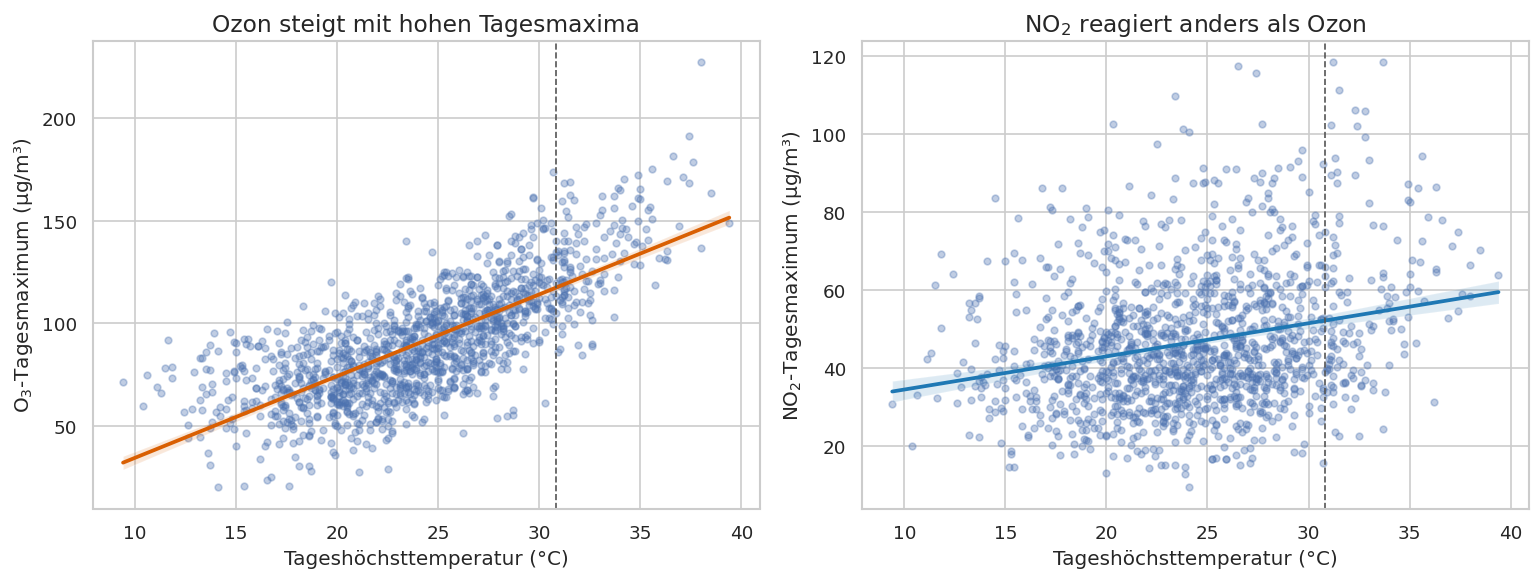

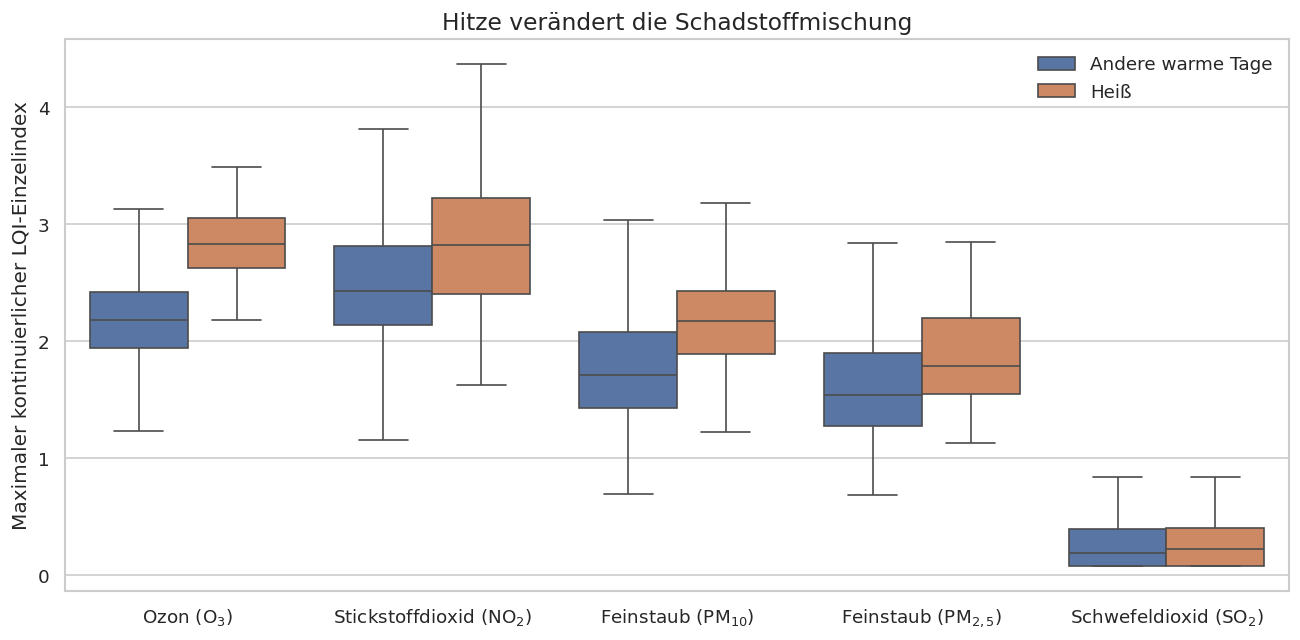

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sample = daily.loc[warm].copy()
sns.regplot(data=sample, x="temp_max_c", y="O3_max", scatter_kws={"s": 16, "alpha": 0.35}, line_kws={"color": COLORS["O3"]}, ax=axes[0])
axes[0].axvline(HOT_THRESHOLD, color="#555555", linestyle="--", linewidth=1)
axes[0].set(title="Ozon steigt mit hohen Tagesmaxima", xlabel="Tageshöchsttemperatur (°C)", ylabel="O$_3$-Tagesmaximum (µg/m³)")
sns.regplot(data=sample, x="temp_max_c", y="NO2_max", scatter_kws={"s": 16, "alpha": 0.35}, line_kws={"color": COLORS["NO2"]}, ax=axes[1])
axes[1].axvline(HOT_THRESHOLD, color="#555555", linestyle="--", linewidth=1)
axes[1].set(title="NO$_2$ reagiert anders als Ozon", xlabel="Tageshöchsttemperatur (°C)", ylabel="NO$_2$-Tagesmaximum (µg/m³)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_temperature_o3_no2.png", bbox_inches="tight")
plt.show()

comparison = daily.loc[warm, score_columns + ["hot_day"]].melt(id_vars="hot_day", var_name="pollutant", value_name="LQI score")
comparison["pollutant"] = comparison["pollutant"].str.replace("_score", "", regex=False).map(LABELS)
comparison["Tagtyp"] = comparison["hot_day"].map({True: "Heiß", False: "Andere warme Tage"})
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=comparison, x="pollutant", y="LQI score", hue="Tagtyp", showfliers=False, ax=ax)
ax.set(title="Hitze verändert die Schadstoffmischung", xlabel="", ylabel="Maximaler kontinuierlicher LQI-Einzelindex")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_hot_day_lqi_scores.png", bbox_inches="tight")
plt.show()

dominant_pollutant,O3,NO2,PM10,PM2.5,SO2
Tagtyp,,,,,
Andere warme Tage,28.1%,64.4%,5.4%,2.1%,0.0%
Heiße Tage,50.3%,47.6%,2.1%,0.0%,0.0%


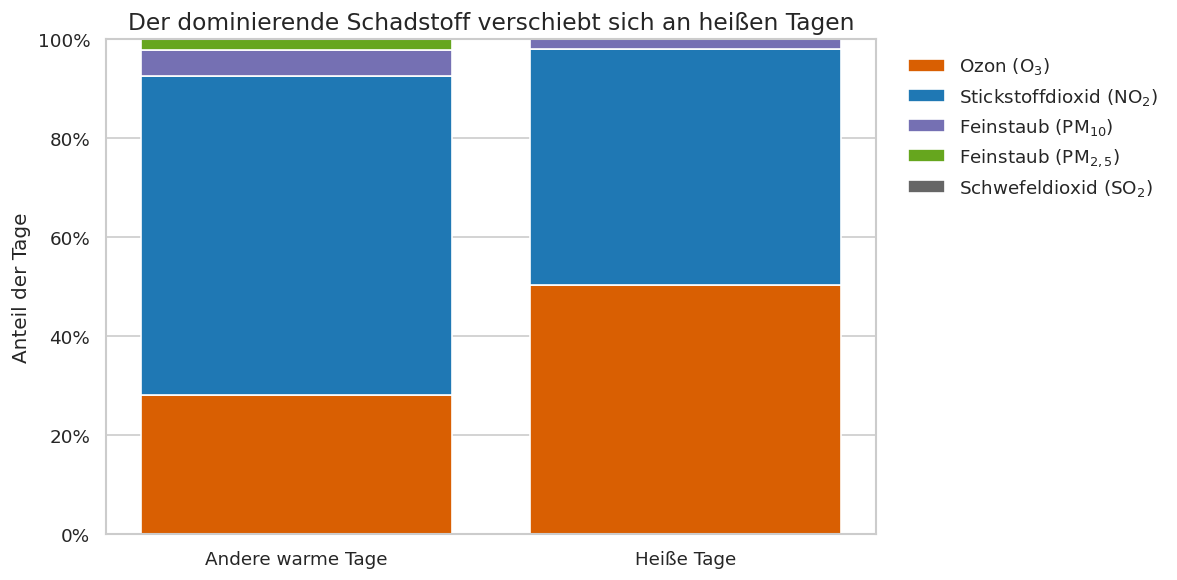

In [6]:
composition = (
    daily.loc[warm]
    .assign(Tagtyp=lambda x: x["hot_day"].map({True: "Heiße Tage", False: "Andere warme Tage"}))
    .groupby("Tagtyp")["dominant_pollutant"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(columns=POLLUTANTS, fill_value=0)
)
display(composition.style.format("{:.1%}"))

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(composition))
for pollutant in POLLUTANTS:
    values = composition[pollutant].to_numpy()
    ax.bar(composition.index, values, bottom=bottom, label=LABELS[pollutant], color=COLORS[pollutant])
    bottom += values
ax.set(title="Der dominierende Schadstoff verschiebt sich an heißen Tagen", xlabel="", ylabel="Anteil der Tage", ylim=(0, 1))
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_dominant_composition.png", bbox_inches="tight")
plt.show()

## 5. Prognose: dominierender Schadstoff am Folgetag

Die Vorhersage kombiniert:

- den aktuellen maximalen LQI-Einzelindex aller fünf Schadstoffe,
- die **Wetterprognose für den Folgetag** (hier im historischen Training durch
  die tatsächlich gemessenen Wetterwerte ersetzt),
- die Jahreszeit als zyklische Variable.

Die letzten zwei Jahre (2024–2025) bleiben vollständig außerhalb des Trainings.
Verglichen werden Mehrheitsklasse, multinomiale logistische Regression und
Random Forest. Die Modellwahl erfolgt nach Macro-F1, damit seltenere
Schadstoffklassen nicht ignoriert werden.

,Accuracy,Balanced Accuracy,Macro-F1
Modell,,,
Random Forest,0.719,0.486,0.497
Logistische Regression,0.581,0.570,0.488
Mehrheitsklasse,0.608,0.250,0.189


Ausgewähltes Modell: Random Forest; Testtage: 732


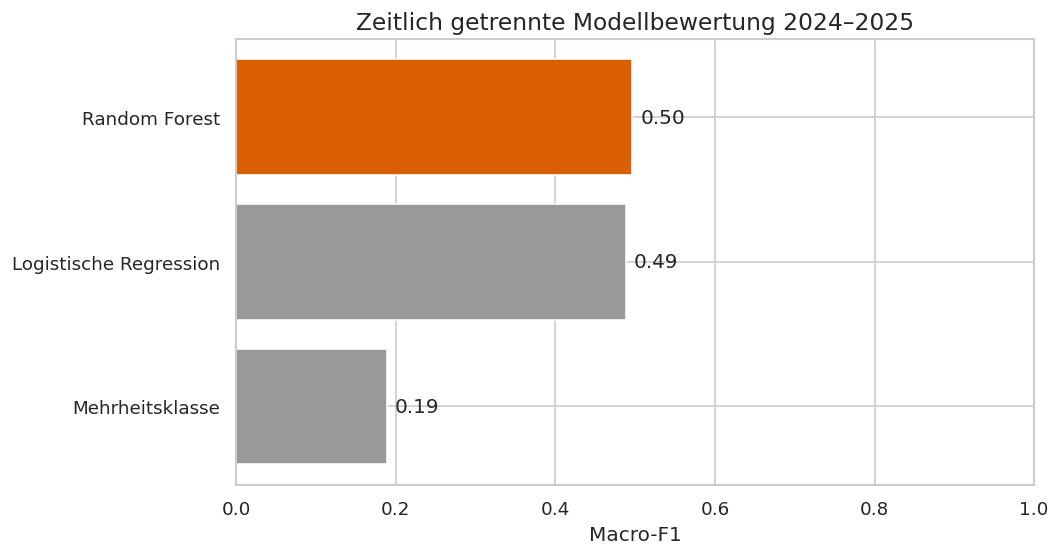

In [7]:
weather_columns = [
    "temp_max_c", "temp_mean_c", "humidity_mean_pct", "wind_mean_ms",
    "precip_sum_mm", "sunshine_sum_h", "global_radiation_sum_j_cm2",
]
current_score_columns = [f"{pollutant}_score" for pollutant in POLLUTANTS]

next_weather = daily[weather_columns].shift(-1).add_prefix("forecast_")
model_data = pd.concat([daily[current_score_columns], next_weather], axis=1)
model_data["target"] = daily["dominant_pollutant"].shift(-1)
model_data["target_date"] = daily.index.to_series().shift(-1)
model_data["day_gap"] = (model_data["target_date"] - model_data.index.to_series()).dt.days
day_of_year = model_data["target_date"].dt.dayofyear
model_data["season_sin"] = np.sin(2 * np.pi * day_of_year / 365.25)
model_data["season_cos"] = np.cos(2 * np.pi * day_of_year / 365.25)
model_data = model_data.loc[model_data["day_gap"].eq(1)].dropna(subset=["target"])

FEATURES = current_score_columns + [f"forecast_{column}" for column in weather_columns] + ["season_sin", "season_cos"]
train_mask = model_data["target_date"] < pd.Timestamp("2024-01-01")
X_train, y_train = model_data.loc[train_mask, FEATURES], model_data.loc[train_mask, "target"]
X_test, y_test = model_data.loc[~train_mask, FEATURES], model_data.loc[~train_mask, "target"]

models = {
    "Mehrheitsklasse": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="prior")),
    ]),
    "Logistische Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500, min_samples_leaf=3, max_features="sqrt",
            class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=1,
        )),
    ]),
}

rows = []
predictions = {}
for name, estimator in models.items():
    estimator.fit(X_train, y_train)
    prediction = estimator.predict(X_test)
    predictions[name] = prediction
    rows.append({
        "Modell": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Balanced Accuracy": balanced_accuracy_score(y_test, prediction),
        "Macro-F1": f1_score(y_test, prediction, average="macro", zero_division=0),
    })

model_comparison = pd.DataFrame(rows).set_index("Modell").sort_values("Macro-F1", ascending=False)
BEST_MODEL_NAME = model_comparison.drop(index="Mehrheitsklasse")["Macro-F1"].idxmax()
best_model = models[BEST_MODEL_NAME]
model_comparison.to_csv(PROCESSED_DIR / "model_comparison.csv")
joblib.dump({"model": best_model, "features": FEATURES, "labels": LABELS}, MODELS_DIR / "dominant_pollutant_model.joblib")

display(model_comparison.style.format("{:.3f}"))
print(f"Ausgewähltes Modell: {BEST_MODEL_NAME}; Testtage: {len(y_test):,}")

fig, ax = plt.subplots(figsize=(9, 4.8))
ordered = model_comparison.sort_values("Macro-F1")
colors = ["#999999" if name != BEST_MODEL_NAME else "#d95f02" for name in ordered.index]
ax.barh(ordered.index, ordered["Macro-F1"], color=colors)
for i, value in enumerate(ordered["Macro-F1"]):
    ax.text(value + 0.01, i, f"{value:.2f}", va="center")
ax.set(title="Zeitlich getrennte Modellbewertung 2024–2025", xlabel="Macro-F1", ylabel="", xlim=(0, 1))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_model_comparison.png", bbox_inches="tight")
plt.show()

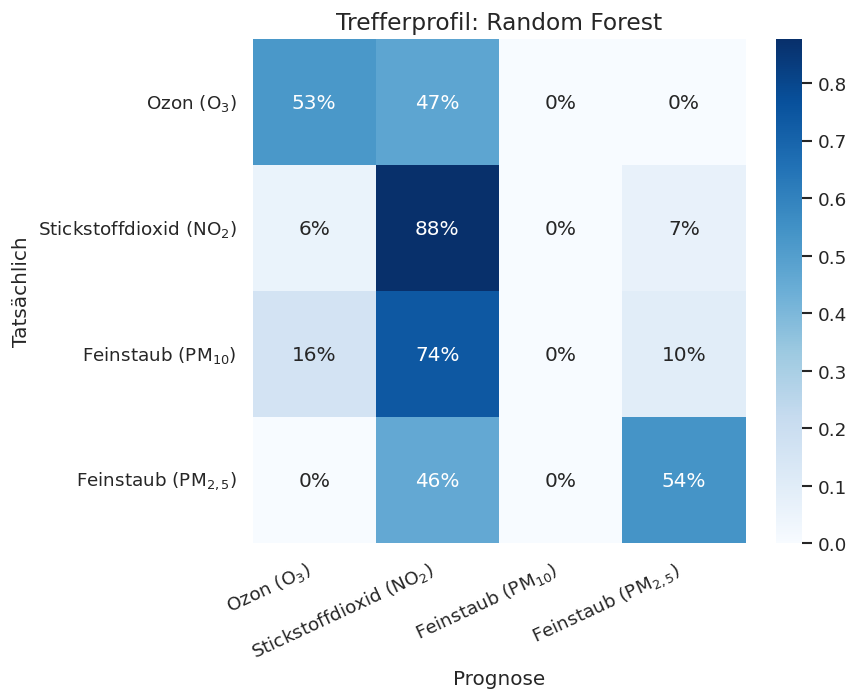

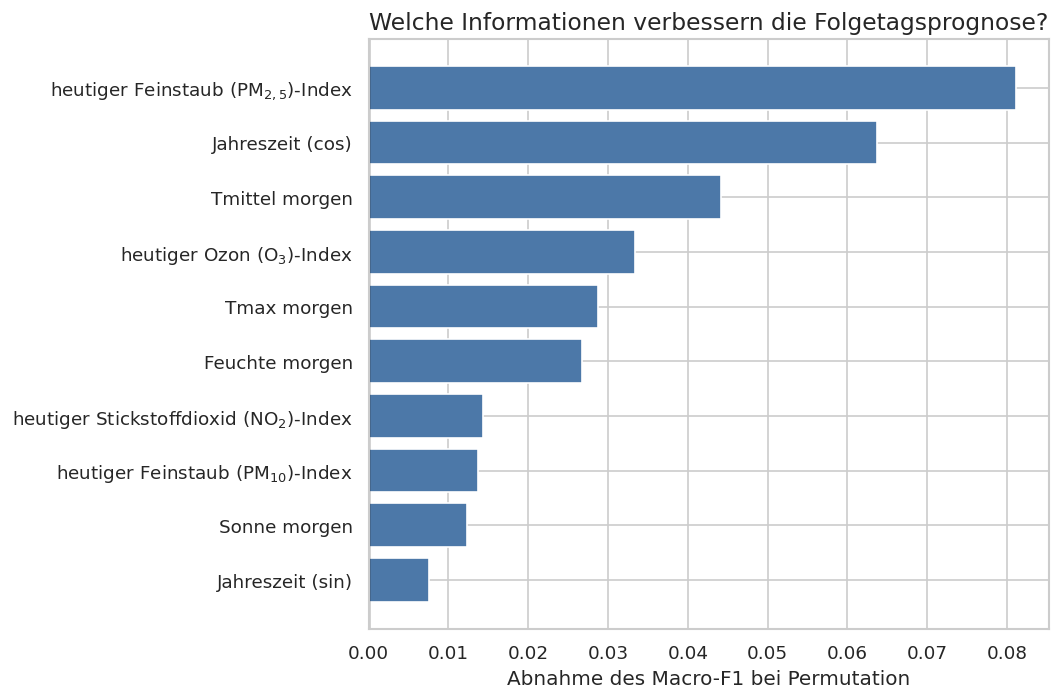

In [8]:
class_order = [label for label in POLLUTANTS if label in set(y_test) | set(predictions[BEST_MODEL_NAME])]
matrix = confusion_matrix(y_test, predictions[BEST_MODEL_NAME], labels=class_order, normalize="true")
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(matrix, annot=True, fmt=".0%", cmap="Blues", xticklabels=[LABELS[x] for x in class_order], yticklabels=[LABELS[x] for x in class_order], ax=ax)
ax.set(title=f"Trefferprofil: {BEST_MODEL_NAME}", xlabel="Prognose", ylabel="Tatsächlich")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_confusion_matrix.png", bbox_inches="tight")
plt.show()

importance = permutation_importance(
    best_model, X_test, y_test, scoring="f1_macro", n_repeats=15,
    random_state=RANDOM_STATE, n_jobs=1,
)
feature_labels = {
    **{f"{p}_score": f"heutiger {LABELS[p]}-Index" for p in POLLUTANTS},
    "forecast_temp_max_c": "Tmax morgen", "forecast_temp_mean_c": "Tmittel morgen",
    "forecast_humidity_mean_pct": "Feuchte morgen", "forecast_wind_mean_ms": "Wind morgen",
    "forecast_precip_sum_mm": "Niederschlag morgen", "forecast_sunshine_sum_h": "Sonne morgen",
    "forecast_global_radiation_sum_j_cm2": "Globalstrahlung morgen",
    "season_sin": "Jahreszeit (sin)", "season_cos": "Jahreszeit (cos)",
}
importance_df = pd.DataFrame({"feature": FEATURES, "importance": importance.importances_mean}).sort_values("importance", ascending=False)
importance_df["label"] = importance_df["feature"].map(feature_labels)
importance_df.to_csv(PROCESSED_DIR / "feature_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 6))
top = importance_df.head(10).sort_values("importance")
ax.barh(top["label"], top["importance"], color="#4c78a8")
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Welche Informationen verbessern die Folgetagsprognose?", xlabel="Abnahme des Macro-F1 bei Permutation", ylabel="")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_feature_importance.png", bbox_inches="tight")
plt.show()

## 6. Interaktive Szenario-Prognose

Die Regler bilden eine Wettervorhersage für morgen und die heute beobachteten
Schadstoff-Einzelindizes ab. Das Modell liefert eine **bedingte Szenario-
prognose**, keine amtliche Luftqualitätswarnung. Im Training wurde gemessenes
Folgetagswetter verwendet; reale Wetterprognosefehler sind daher nicht in der
Modellgüte enthalten.

In [9]:
import ipywidgets as widgets


def quantile_range(column, fallback):
    values = model_data[column].dropna()
    if values.empty:
        return fallback
    return float(values.quantile(0.01)), float(values.quantile(0.99)), float(values.median())


slider_specs = {
    "forecast_temp_max_c": ("Tmax morgen (°C)", -10, 42, 0.5),
    "forecast_temp_mean_c": ("Tmittel morgen (°C)", -15, 35, 0.5),
    "forecast_humidity_mean_pct": ("Feuchte morgen (%)", 20, 100, 1),
    "forecast_wind_mean_ms": ("Wind morgen (m/s)", 0, 15, 0.1),
    "forecast_precip_sum_mm": ("Regen morgen (mm)", 0, 40, 0.5),
    "forecast_sunshine_sum_h": ("Sonne morgen (h)", 0, 16, 0.25),
    "forecast_global_radiation_sum_j_cm2": ("Globalstrahlung (J/cm²)", 0, 3500, 25),
}

controls = {}
for feature, (description, minimum, maximum, step) in slider_specs.items():
    _, _, median = quantile_range(feature, (minimum, maximum, (minimum + maximum) / 2))
    controls[feature] = widgets.FloatSlider(
        description=description, min=minimum, max=maximum, step=step,
        value=float(np.clip(median, minimum, maximum)), continuous_update=False,
        style={"description_width": "180px"}, layout=widgets.Layout(width="520px"),
    )

for pollutant in POLLUTANTS:
    feature = f"{pollutant}_score"
    controls[feature] = widgets.FloatSlider(
        description=f"{LABELS[pollutant]} heute", min=0, max=5, step=0.1,
        value=float(model_data[feature].median()), continuous_update=False,
        style={"description_width": "180px"}, layout=widgets.Layout(width="520px"),
    )

month_control = widgets.IntSlider(
    description="Monat morgen", min=1, max=12, step=1, value=7,
    continuous_update=False, style={"description_width": "180px"},
    layout=widgets.Layout(width="520px"),
)
output = widgets.Output()


def update_prediction(change=None):
    month = month_control.value
    approximate_doy = pd.Timestamp(2025, month, 15).dayofyear
    row = {feature: control.value for feature, control in controls.items()}
    row["season_sin"] = np.sin(2 * np.pi * approximate_doy / 365.25)
    row["season_cos"] = np.cos(2 * np.pi * approximate_doy / 365.25)
    scenario = pd.DataFrame([row], columns=FEATURES)
    probabilities = best_model.predict_proba(scenario)[0]
    classes = best_model.named_steps["model"].classes_
    order = np.argsort(probabilities)
    predicted = classes[order[-1]]
    with output:
        output.clear_output(wait=True)
        display(Markdown(f"### Prognose: **{LABELS[predicted]}** dominiert morgen"))
        fig, ax = plt.subplots(figsize=(8, 3.5))
        ax.barh([LABELS[c] for c in classes[order]], probabilities[order], color=[COLORS[c] for c in classes[order]])
        ax.set(xlim=(0, 1), xlabel="Modellwahrscheinlichkeit", ylabel="")
        ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
        plt.tight_layout()
        plt.show()


for control in [*controls.values(), month_control]:
    control.observe(update_prediction, names="value")

display(widgets.VBox([month_control, *controls.values(), output]))
update_prediction()

## 7. Fazit, Grenzen und Export

Die Kernaussage wird direkt aus den berechneten Werten erzeugt. Wesentliche
Grenzen bleiben: Beobachtungsdaten belegen keine Kausalität; nur ein urbaner
Standort wird untersucht; Verkehr, Ferntransport und chemische Vorläufer sind
nicht direkt beobachtet; die Wetterprognose wird historisch als fehlerfrei
angenommen; seltene Dominanzklassen erschweren die Mehrklassenprognose.

In [10]:
hot_composition = composition.loc["Heiße Tage"].to_dict()
reference_composition = composition.loc["Andere warme Tage"].to_dict()
analysis_summary = {
    "period": f"{START_YEAR}-{END_YEAR}",
    "hourly_air_rows": int(len(air)),
    "hourly_merged_rows": int(len(hourly)),
    "daily_rows": int(len(daily)),
    "station_distance_km": distance_km,
    "hot_threshold_c": HOT_THRESHOLD,
    "hot_day_count": int(daily["hot_day"].sum()),
    "o3_median_difference_ug_m3": o3_diff,
    "o3_p_value_one_sided": float(o3_test.pvalue),
    "no2_median_difference_ug_m3": no2_diff,
    "no2_p_value_one_sided": float(no2_test.pvalue),
    "thesis_supported": bool(thesis_supported),
    "hot_day_dominant_shares": hot_composition,
    "reference_dominant_shares": reference_composition,
    "best_model": BEST_MODEL_NAME,
    "test_days": int(len(y_test)),
    "test_accuracy": float(model_comparison.loc[BEST_MODEL_NAME, "Accuracy"]),
    "test_balanced_accuracy": float(model_comparison.loc[BEST_MODEL_NAME, "Balanced Accuracy"]),
    "test_macro_f1": float(model_comparison.loc[BEST_MODEL_NAME, "Macro-F1"]),
}
(PROCESSED_DIR / "analysis_summary.json").write_text(json.dumps(analysis_summary, ensure_ascii=False, indent=2), encoding="utf-8")

display(Markdown(f'''
### Antwort auf die Forschungsfrage

An heißen Tagen verändert sich vor allem die **Zusammensetzung** der Belastung:
Ozon verschiebt sich um {o3_diff:+.1f} µg/m³, NO₂ um {no2_diff:+.1f} µg/m³
gegenüber anderen warmen Tagen. Die These wird statistisch
**{'unterstützt' if thesis_supported else 'nicht vollständig unterstützt'}**.

Für den Folgetag erreicht das Modell „{BEST_MODEL_NAME}“ auf den vollständig
zurückgehaltenen Jahren 2024–2025 eine Accuracy von
{model_comparison.loc[BEST_MODEL_NAME, 'Accuracy']:.1%} und einen Macro-F1 von
{model_comparison.loc[BEST_MODEL_NAME, 'Macro-F1']:.2f}. Die Prognose ist ein
Lernmodell für Szenarien, nicht die amtliche UBA-Prognose.
'''))


### Antwort auf die Forschungsfrage

An heißen Tagen verändert sich vor allem die **Zusammensetzung** der Belastung:
Ozon verschiebt sich um +46.7 µg/m³, NO₂ um +11.9 µg/m³
gegenüber anderen warmen Tagen. Die These wird statistisch
**nicht vollständig unterstützt**.

Für den Folgetag erreicht das Modell „Random Forest“ auf den vollständig
zurückgehaltenen Jahren 2024–2025 eine Accuracy von
71.9% und einen Macro-F1 von
0.50. Die Prognose ist ein
Lernmodell für Szenarien, nicht die amtliche UBA-Prognose.


## 8. Quellen und Dokumentation der KI-Nutzung

**Amtliche Daten und Methodik**

- Hessisches Landesamt für Naturschutz, Umwelt und Geologie (HLNUG):
  Messdatenportal und Station Frankfurt-Höchst (DEHE005):
  https://www.hlnug.de/messwerte/datenportal/messstelle/2/1/0617/6/1/1748048400
- UBA-Luftqualitätsindex und aktuelle Klassengrenzen:
  https://www.umweltbundesamt.de/themen/luft/luftqualitaet/der-luftqualitaetsindex-lqi
- Deutscher Wetterdienst, Climate Data Center: stündliche Stationsmessungen
  für Temperatur/Feuchte, Wind, Sonnenschein, Niederschlag und Solarstrahlung:
  https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/

Die HLNUG-Daten wurden bereits in UTC abgefragt; DWD-Zeiten liegen ebenfalls
in UTC vor. Rohdateien, URLs, Abrufzeit und SHA-256-Prüfsummen stehen in
`data/raw/download_manifest.json`.

**KI-Nutzung**

Generative KI unterstützte Projektstruktur, Codeentwurf, Modellvergleich,
Visualisierungen und Präsentation. KI-Ausgaben wurden nicht als Datenquelle
verwendet. Die Ergebnisse entstehen reproduzierbar aus amtlichen Daten; die
Modellwahl basiert auf einem zeitlich getrennten Test. Das vollständige
Einsatzprotokoll und die menschlichen Kontrollschritte stehen in
`KI_NUTZUNG.md`.